# 1. Extracción y preprocesamiento de los datos

## 1.1. Introducción

Este notebook forma parte del proyecto **“Clasificación de Leads de Streaming de Películas”** y constituye la **fase inicial de preparación de los datos** sobre la que se construirá el modelo de clasificación.

Su objetivo es **construir un dataset limpio, coherente y libre de *data leakage*** a partir de datos de clientes del sector telecomunicaciones, con el fin de **predecir la probabilidad de contratación del servicio *Streaming Movies***. Esta probabilidad se expresará posteriormente como un *propensity score* entre 0 y 1 para priorizar leads y optimizar campañas de marketing.

A lo largo del notebook se realiza un **análisis exploratorio (EDA)** y un **proceso sistemático de transformación, limpieza y codificación de variables**, combinando criterios estadísticos y de negocio. Se pone especial énfasis en la detección de variables redundantes, altamente correlacionadas o que puedan revelar implícitamente el target.

Los datos utilizados incluyen información demográfica, contractual, de consumo y facturación. Las variables derivadas del churn o que incorporan información posterior a la decisión de contratación se excluyen deliberadamente para garantizar la validez del modelo.

**Objetivos del Notebook**

1. **Cargar y unificar los datos originales** para realizar un EDA global y consistente.  
2. **Analizar la estructura y calidad del dataset**, identificando distribuciones, asimetrías y valores nulos.  
3. **Evaluar la relación entre variables y el target**, descartando aquellas sin poder predictivo.  
4. **Aplicar transformaciones y limpieza de datos** para mejorar la estabilidad del modelado y evitar *data leakage*.  
5. **Codificar las variables categóricas** y generar el **dataset final listo para modelado**.


**Dataset:** https://huggingface.co/datasets/aai510-group1/telco-customer-churn

## 1.2. Importación de librerías y base de datos

Se importan las librerías necesarias para análisis exploratorio, visualización y posteriores
etapas de modelado.

In [1]:
#Importación de librerías
import pandas as pd
import numpy as np
import sklearn as sk
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset
plt.style.use('bmh')

c:\Users\Cristina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Se unifican los conjuntos de entrenamiento, validación y test para realizar un EDA global
y coherente sobre toda la muestra.

In [2]:
import sys
sys.path.append(r"H:\Cristina\Mis documentos\Github\TFM-1-Clasificacion_leads\src")

from data_loading import load_telco_data
df = load_telco_data()

In [3]:
df

,Age,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Churn,Churn Category,Churn Reason,Churn Score,City,CLTV,Contract,...,Tenure in Months,Total Charges,Total Extra Data Charges,Total Long Distance Charges,Total Refunds,Total Revenue,Under 30,Unlimited Data,Zip Code,split
0,72,4,19.44,0,None,None,51,San Mateo,4849,Two Year,...,25,2191.15,0,486.00,0.0,2677.15,0,1,94403,train
1,27,59,45.62,0,None,None,27,Sutter Creek,3715,Month-to-Month,...,35,3418.20,0,1596.70,0.0,5014.90,1,1,95685,train
2,59,0,16.07,0,None,None,59,Santa Cruz,5092,Month-to-Month,...,46,851.20,0,739.22,0.0,1590.42,0,0,95064,train
3,25,27,0.00,0,None,None,49,Brea,2068,One Year,...,27,1246.40,30,0.00,0.0,1276.40,1,0,92823,train
4,31,21,17.22,1,Dissatisfaction,Network reliability,88,San Jose,4026,One Year,...,58,3563.80,0,998.76,0.0,4562.56,0,1,95117,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,33,12,10.67,0,None,None,53,Clayton,4847,Month-to-Month,...,29,2878.75,0,309.43,0.0,3188.18,0,1,94517,test
7039,36,30,30.44,0,None,None,45,Nicolaus,5470,Two Year,...,59,5655.45,0,1795.96,0.0,7451.41,0,1,95659,test
7040,57,24,4.51,0,None,None,74,Walnut Creek,4471,Two Year,...,61,5175.30,0,275.11,0.0,5450.41,0,1,94596,test
7041,35,24,47.06,0,None,None,70,Valyermo,5445,Two Year,...,30,1653.85,0,1411.80,0.0,3065.65,0,1,93563,test


In [4]:
pd.set_option('display.max_columns', None)

## 1.3. Exploración de los datos (EDA)

Se realiza una primera inspección del dataset para entender su estructura, tipos de variables, volumen de datos y posibles problemas de calidad (nulos, tipos incorrectos, etc.).

### A ) Estructura de los datos

In [5]:
#Vista rápida de los datos
df.head()

,Age,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Churn,Churn Category,Churn Reason,Churn Score,City,CLTV,Contract,Country,Customer ID,Customer Status,Dependents,Device Protection Plan,Gender,Internet Service,Internet Type,Lat Long,Latitude,Longitude,Married,Monthly Charge,Multiple Lines,Number of Dependents,Number of Referrals,Offer,Online Backup,Online Security,Paperless Billing,Partner,Payment Method,Phone Service,Population,Premium Tech Support,Quarter,Referred a Friend,Satisfaction Score,Senior Citizen,State,Streaming Movies,Streaming Music,Streaming TV,Tenure in Months,Total Charges,Total Extra Data Charges,Total Long Distance Charges,Total Refunds,Total Revenue,Under 30,Unlimited Data,Zip Code,split
0,72,4,19.44,0,None,None,51,San Mateo,4849,Two Year,United States,4526-ZJJTM,Stayed,0,1,Female,1,Fiber Optic,"37.538309, -122.305109",37.538309,-122.305109,1,88.40,0,0,1,None,1,0,0,1,Bank Withdrawal,1,37926,0,Q3,1,3,1,California,1,1,0,25,2191.15,0,486.00,0.0,2677.15,0,1,94403,train
1,27,59,45.62,0,None,None,27,Sutter Creek,3715,Month-to-Month,United States,5302-BDJNT,Stayed,0,1,Male,1,Fiber Optic,"38.432145, -120.77069",38.432145,-120.770690,0,95.50,1,0,0,None,0,0,0,0,Bank Withdrawal,1,4610,1,Q3,0,3,0,California,0,0,1,35,3418.20,0,1596.70,0.0,5014.90,1,1,95685,train
2,59,0,16.07,0,None,None,59,Santa Cruz,5092,Month-to-Month,United States,5468-BPMMO,Stayed,0,0,Male,0,None,"37.007882, -122.065975",37.007882,-122.065975,1,19.60,0,0,3,None,0,0,0,1,Bank Withdrawal,1,4563,0,Q3,1,5,0,California,0,0,0,46,851.20,0,739.22,0.0,1590.42,0,0,95064,train
3,25,27,0.00,0,None,None,49,Brea,2068,One Year,United States,2212-LYASK,Stayed,0,1,Male,1,DSL,"33.924143, -117.79387",33.924143,-117.793870,1,45.85,0,0,3,None,1,0,1,1,Credit Card,0,1408,0,Q3,1,4,0,California,1,1,0,27,1246.40,30,0.00,0.0,1276.40,1,0,92823,train
4,31,21,17.22,1,Dissatisfaction,Network reliability,88,San Jose,4026,One Year,United States,0378-XSZPU,Churned,0,1,Male,1,Cable,"37.311088, -121.961786",37.311088,-121.961786,1,60.30,0,0,1,Offer B,1,1,0,1,Credit Card,1,29914,0,Q3,1,2,0,California,0,0,0,58,3563.80,0,998.76,0.0,4562.56,0,1,95117,train


La vista inicial confirma la presencia de variables demográficas, contractuales,
de consumo y facturación.


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 53 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                7043 non-null   int64  
 1   Avg Monthly GB Download            7043 non-null   int64  
 2   Avg Monthly Long Distance Charges  7043 non-null   float64
 3   Churn                              7043 non-null   int64  
 4   Churn Category                     1869 non-null   object 
 5   Churn Reason                       1869 non-null   object 
 6   Churn Score                        7043 non-null   int64  
 7   City                               7043 non-null   object 
 8   CLTV                               7043 non-null   int64  
 9   Contract                           7043 non-null   object 
 10  Country                            7043 non-null   object 
 11  Customer ID                        7043 non-null   objec

El dataset combina variables numéricas, categóricas y binarias.
No se observan problemas de tipos, aunque algunas variables presentan valores nulos.


In [7]:
#Análisis univariado
df.describe(include='all')

,Age,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Churn,Churn Category,Churn Reason,Churn Score,City,CLTV,Contract,Country,Customer ID,Customer Status,Dependents,Device Protection Plan,Gender,Internet Service,Internet Type,Lat Long,Latitude,Longitude,Married,Monthly Charge,Multiple Lines,Number of Dependents,Number of Referrals,Offer,Online Backup,Online Security,Paperless Billing,Partner,Payment Method,Phone Service,Population,Premium Tech Support,Quarter,Referred a Friend,Satisfaction Score,Senior Citizen,State,Streaming Movies,Streaming Music,Streaming TV,Tenure in Months,Total Charges,Total Extra Data Charges,Total Long Distance Charges,Total Refunds,Total Revenue,Under 30,Unlimited Data,Zip Code,split
count,7043.000000,7043.000000,7043.000000,7043.000000,1869,1869,7043.000000,7043,7043.000000,7043,7043,7043,7043,7043.000000,7043.000000,7043,7043.000000,5517,7043,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,3166,7043.000000,7043.000000,7043.000000,7043.000000,7043,7043.000000,7043.000000,7043.000000,7043,7043.000000,7043.000000,7043.000000,7043,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043,7043
unique,NaN,NaN,NaN,NaN,5,20,NaN,1106,NaN,3,1,7043,3,NaN,NaN,2,NaN,3,1679,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,1,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1626,3
top,NaN,NaN,NaN,NaN,Competitor,Competitor had better devices,NaN,Los Angeles,NaN,Month-to-Month,United States,4526-ZJJTM,Stayed,NaN,NaN,Male,NaN,Fiber Optic,"33.362575, -117.299644",NaN,NaN,NaN,NaN,NaN,NaN,NaN,Offer B,NaN,NaN,NaN,NaN,Bank Withdrawal,NaN,NaN,NaN,Q3,NaN,NaN,NaN,California,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92028,train
freq,NaN,NaN,NaN,NaN,841,313,NaN,293,NaN,3610,7043,1,4720,NaN,NaN,3555,NaN,3035,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,824,NaN,NaN,NaN,NaN,3909,NaN,NaN,NaN,7043,NaN,NaN,NaN,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43,4225
mean,46.509726,20.515405,22.958954,0.265370,NaN,NaN,58.505040,NaN,4400.295755,NaN,NaN,NaN,NaN,0.231010,0.343888,NaN,0.783331,NaN,NaN,36.197455,-119.756684,0.483033,64.761692,0.421837,0.468692,1.951867,NaN,0.344881,0.286668,0.592219,0.483033,NaN,0.903166,22139.603294,0.290217,NaN,0.457476,3.244924,0.162147,NaN,0.387903,0.353259,0.384353,32.386767,2280.381264,6.860713,749.099262,1.962182,3034.379056,0.198921,0.673719,NaN,NaN
std,16.750352,20.418940,15.448113,0.441561,NaN,NaN,21.170031,NaN,1183.057152,NaN,NaN,NaN,NaN,0.421508,0.475038,NaN,0.412004,NaN,NaN,2.468929,2.154425,0.499748,30.090047,0.493888,0.962802,3.001199,NaN,0.475363,0.452237,0.491457,0.499748,NaN,0.295752,21152.392837,0.453895,NaN,0.498224,1.201657,0.368612,NaN,0.487307,0.478016,0.486477,24.542061,2266.220462,25.104978,846.660055,7.902614,2865.204542,0.399217,0.468885,NaN,NaN
min,19.000000,0.000000,0.000000,0.000000,NaN,NaN,5.000000,NaN,2003.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,0.000000,NaN,NaN,32.555828,-124.301372,0.000000,18.250000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,11.000000,0.000000,NaN,0.000000,1.000000,0.000000,NaN,0.000000,0.000000,0.000000,1.000000,18.800000,0.000000,0.000000,0.000000,21.360000,0.000000,0.000000,NaN,NaN
25%,32.000000,3.000000,9.210000,0.000000,NaN,NaN,40.000000,NaN,3469.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,1.000000,NaN,NaN,33.990646,-121.788090,0.000000,35.500000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,2344.000000,0.000000,NaN,0.000000,3.000000,0.000000,NaN,0.000000,0.000000,0.000000,9.000000,400.150000,0.000000,70.545000,0.000000,605.610000,0.000000,0.000000,NaN,NaN
50%,46.000000,17.000000,22.890000,0.000000,NaN,NaN,61.000000,NaN,4527.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,1.000000,NaN,NaN,36.205465,-119.595293,0.000000,70.350000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,1.000000,0.000000,NaN,1.000000,17554.000000,0.000000,NaN,0.000000,3.000

La tabla de estadísticas descriptivas muestra una muestra completa de 7.043 clientes, sin pérdidas relevantes en la mayoría de variables.
*   Streaming Movies presenta una media de 0,39 aproximadamente y una mediana (percentil 50) de 0 lo que indica que más de la mitad de los clientes no tienen contratado el servicio de Streaming Movies.
La desviación estándar cercana a 0,5 es la esperada en una variable binaria y confirma que no existe un desbalance extremo. En conjunto, los estadísticos de la variable objetivo son adecuados y no suponen un problema para el modelado, ya que ambas clases están bien representadas.

*   Destacan las variables de cargos y facturación (Total Revenue, Total Charges, Total Long Distance Charges), que presentan medias claramente superiores a las medianas y desviaciones estándar elevadas, confirmando distribuciones asimétricas con colas largas.

*   En las variables binarias, como Under 30, Unlimited Data y Churn, las medias indican proporciones razonables y bien distribuidas, sin desbalances extremos. En particular, Churn presenta una tasa media cercana al 26%, coherente con el contexto del sector.

*   Las variables como Total Refunds presentan una mediana igual a cero, indicando inflación de ceros y bajo contenido informativo.


En conjunto, la tabla confirma la necesidad de transformar variables de consumo, agrupar o discretizar variables muy dispersas y eliminar variables de alta cardinalidad o baja señal antes del modelado.


In [8]:
#Observar la distribución de categoría y valores de cada columna
for col in df.columns:
    print(col, df[col].unique())

Age [72 27 59 25 31 32 36 48 54 67 79 20 30 62 71 22 38 46 47 68 60 50 80 76
 34 28 69 35 37 39 63 44 74 66 33 58 19 56 26 49 42 23 41 61 75 43 29 21
 45 77 73 64 24 78 53 55 40 51 57 52 65 70]
Avg Monthly GB Download [ 4 59  0 27 21 30  8 16 14 12 22  2 71 23  7 13  9 20  3 19 28  5 10 11
 52 56  6 76 15 26 57 85 51 24 25 18 48 53 73 17 69 29 41 47 42 82 75 58
 46 39]
Avg Monthly Long Distance Charges [19.44 45.62 16.07 ... 48.84 42.74  1.4 ]
Churn [0 1]
Churn Category [None 'Dissatisfaction' 'Competitor' 'Price' 'Attitude' 'Other']
Churn Reason [None 'Network reliability' 'Competitor had better devices'
 'Price too high' 'Competitor offered higher download speeds'
 'Competitor offered more data' 'Attitude of support person'
 'Competitor made better offer' "Don't know"
 'Attitude of service provider' 'Limited range of services'
 'Product dissatisfaction' 'Long distance charges'
 'Poor expertise of online support'
 'Lack of affordable download/upload speed' 'Service dissatisfaction'
 '

In [9]:
df.isnull().sum()

Age                                     0
Avg Monthly GB Download                 0
Avg Monthly Long Distance Charges       0
Churn                                   0
Churn Category                       5174
Churn Reason                         5174
Churn Score                             0
City                                    0
CLTV                                    0
Contract                                0
Country                                 0
Customer ID                             0
Customer Status                         0
Dependents                              0
Device Protection Plan                  0
Gender                                  0
Internet Service                        0
Internet Type                        1526
Lat Long                                0
Latitude                                0
Longitude                               0
Married                                 0
Monthly Charge                          0
Multiple Lines                    

Observando el contenido de las variables determinamos el tipo de variable que es cada una:

- **Binarias (0/1)**  Listas para modelado, sin nulos.

  `Streaming Movies`, `Streaming Music`, `Streaming TV`, `Churn`, `Under 30`, `Unlimited Data`, `Dependents`, `Device Protection Plan`, `Internet Service`, `Married`, `Multiple Lines`, `Online Backup`, `Online Security`, `Paperless Billing`, `Partner`, `Phone Service`, `Premium Tech Support`, `Referred a Friend`, `Senior Citizen`.  
  

- **Numéricas continuas** Gran diversidad de valores, sin nulos.

  `Age`, `Avg Monthly GB Download`, `Avg Monthly Long Distance Charges`, `Churn Score`, `CLTV`, `Monthly Charge`, `Tenure in Months`, `Total Charges`, `Total Extra Data Charges`, `Total Long Distance Charges`, `Total Refunds`, `Total Revenue`, `Population`.  
  

- **Categorías con pocos valores únicos** Necesitan codificación.

  `Contract`, `Payment Method`, `Quarter`, `State`.  
  

- **Categorías con alta cardinalidad**  No aportan información útil para el modelo.

  `City`, `Zip Code`, `Customer ID`, `Lat Long`, `Latitude`, `Longitude`.  
  

- **Categorías con nulos significativos** Estás variables apenas aportan información para predecir si un cliente contratará el servicio de streaming de películas. Además los NaN se deben a que:

  `Churn Category`: El cliente que ha abandonado no ha rellenado este campo en la encuesta de cancelación de contrato.
  `Churn Reason` : El cliente que ha abandonado no ha rellenado este campo en la encuesta de cancelación de contrato.
  `Internet Type` : El cliente no tiene contratado el servicio de Internet
  `Offer` :  El cliente no ha recibido la oferta.

- **Variable objetivo**  está completa, binaria y lista para modelado.

  `Streaming Movies`


In [10]:
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0]

missing_percent = (missing_data / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage (%)': missing_percent
})

missing_table = missing_table.sort_values(by='Missing Percentage (%)', ascending=False)

print(missing_table)

                Missing Count  Missing Percentage (%)
Churn Category           5174               73.463013
Churn Reason             5174               73.463013
Offer                    3877               55.047565
Internet Type            1526               21.666903


In [11]:
internet_type_nan_and_service = df[df['Internet Type'].isnull()]['Internet Service'].sum()

if internet_type_nan_and_service == 0:
    print("Confirmado: Los valores NaN en 'Internet Type' corresponden a clientes que no tienen contratado 'Internet Service'.")
else:
    print(f"Hay {internet_type_nan_and_service} clientes con NaN en 'Internet Type' que sí tienen 'Internet Service' contratado.")

Confirmado: Los valores NaN en 'Internet Type' corresponden a clientes que no tienen contratado 'Internet Service'.


### B ) Análisis univariado

En esta sección exploramos cada variable individualmente para comprender su distribución, rango de valores y características principales.  
Para variables numéricas se revisan estadísticas como media, mediana y desviación estándar, mientras que para variables categóricas y binarias se analizan frecuencias y proporciones.  
Este análisis permite identificar patrones, valores atípicos y necesidades de transformación antes de avanzar al modelado.

Para mantener una separación correcta entre tipos de variables durante el EDA, distinguimos tres grupos:
*   Numéricas (edad, cargos, consumos, etc.)
*   Categóricas verdaderas (Contract, Payment Method, Internet Type…)
*   Variables binarias codificadas a 0/1 (Partner, Gender, Paperless Billing…)

In [12]:
#Distinguimos las variables binarias
binary_vars = [
    "Dependents", "Device Protection Plan", "Internet Service",
    "Married", "Multiple Lines", "Online Backup", "Online Security",
    "Paperless Billing", "Partner", "Phone Service",
    "Premium Tech Support", "Referred a Friend", "Senior Citizen",
    "Streaming Movies", "Streaming Music", "Streaming TV",
    "Under 30", "Unlimited Data", "Churn"
]

In [13]:
#Definimos las variables numéricas y categóricas
num_cols_raw = df.select_dtypes(include=np.number).columns.tolist()
cat_cols_raw = df.select_dtypes(include="object").columns.tolist()
cat_and_binary_raw = df.select_dtypes(include="object").columns.tolist() + [col for col in binary_vars if col in df.columns]

print("Numéricas originales:", num_cols_raw)
print("Categóricas originales:", cat_cols_raw)
print("Categóricas y binarias originales:", cat_and_binary_raw)

Numéricas originales: ['Age', 'Avg Monthly GB Download', 'Avg Monthly Long Distance Charges', 'Churn', 'Churn Score', 'CLTV', 'Dependents', 'Device Protection Plan', 'Internet Service', 'Latitude', 'Longitude', 'Married', 'Monthly Charge', 'Multiple Lines', 'Number of Dependents', 'Number of Referrals', 'Online Backup', 'Online Security', 'Paperless Billing', 'Partner', 'Phone Service', 'Population', 'Premium Tech Support', 'Referred a Friend', 'Satisfaction Score', 'Senior Citizen', 'Streaming Movies', 'Streaming Music', 'Streaming TV', 'Tenure in Months', 'Total Charges', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Refunds', 'Total Revenue', 'Under 30', 'Unlimited Data']
Categóricas originales: ['Churn Category', 'Churn Reason', 'City', 'Contract', 'Country', 'Customer ID', 'Customer Status', 'Gender', 'Internet Type', 'Lat Long', 'Offer', 'Payment Method', 'Quarter', 'State', 'Zip Code', 'split']
Categóricas y binarias originales: ['Churn Category', 'Churn Reas

In [14]:
#Selección de variables numéricas
num = [
    col for col in df.columns
    if df[col].dtype in [int, float]
    and col not in binary_vars
]

#### Variables numéricas

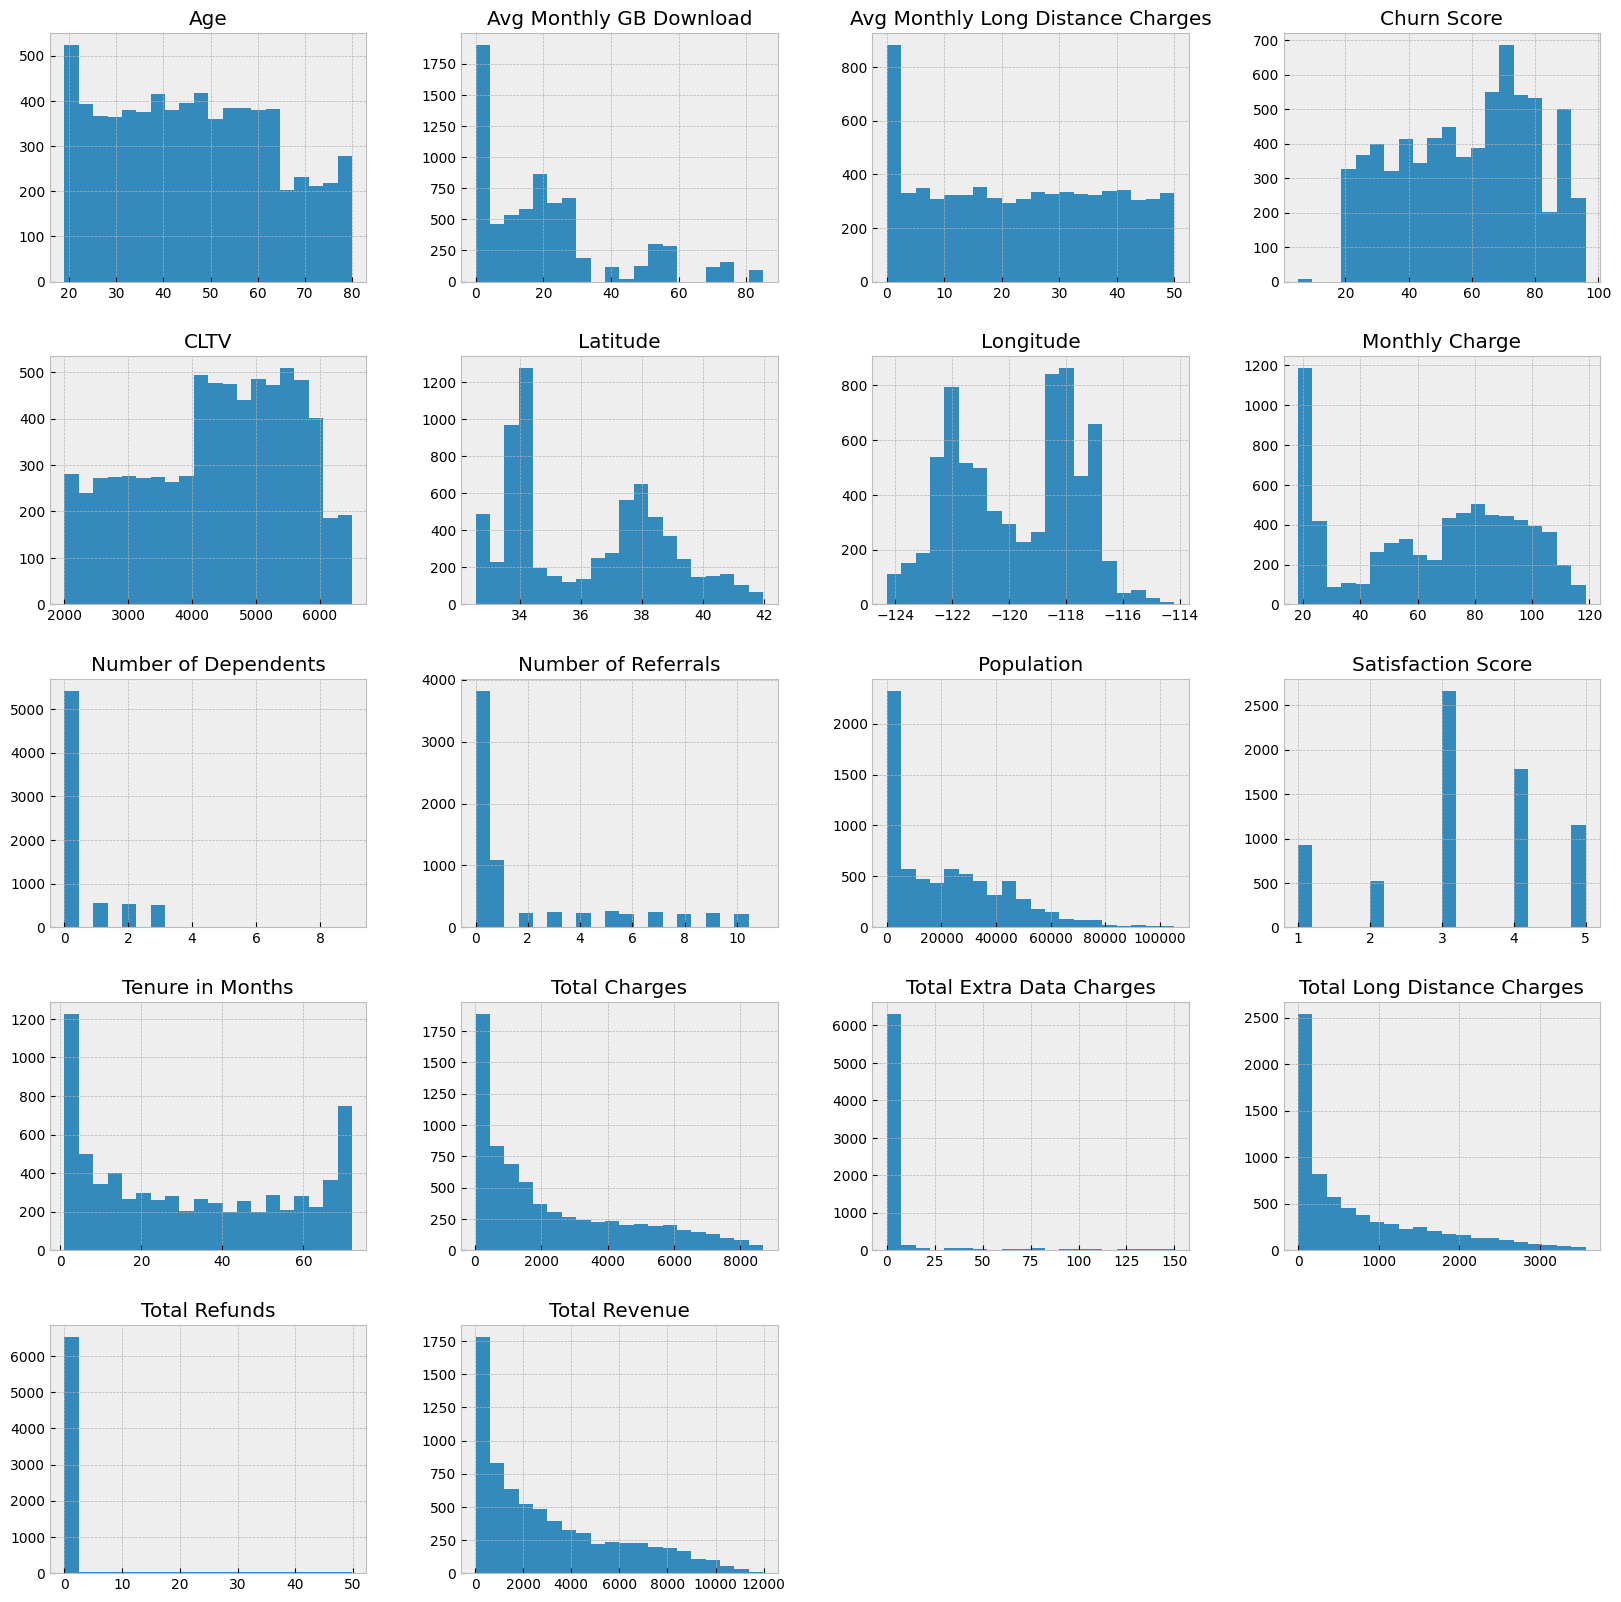

In [15]:
#Representación variables numéricas
df[num].hist(bins=20, figsize=(20,20))
plt.show()

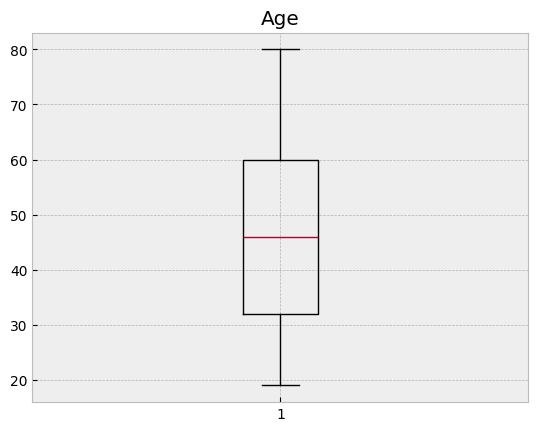

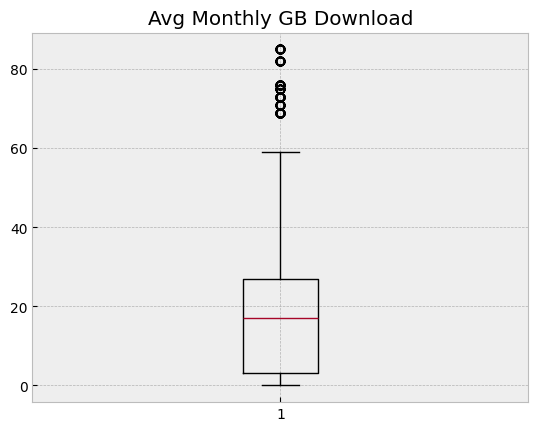

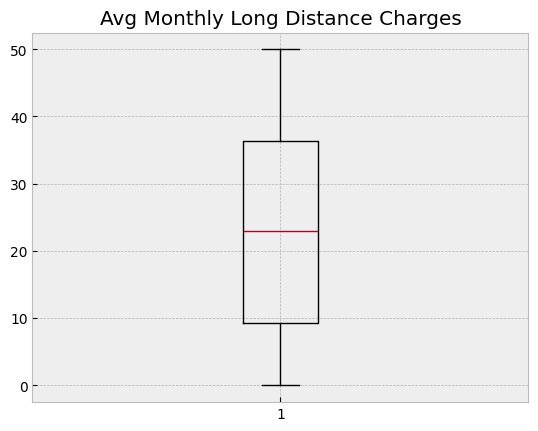

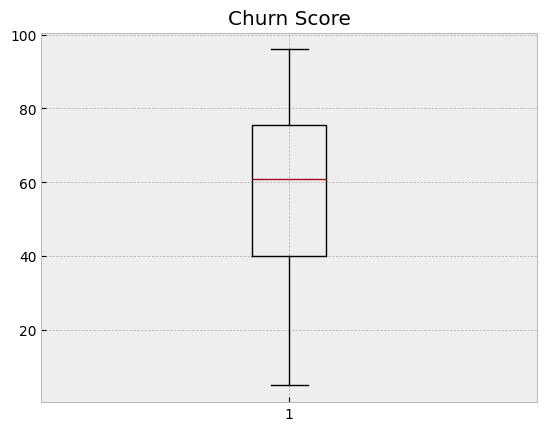

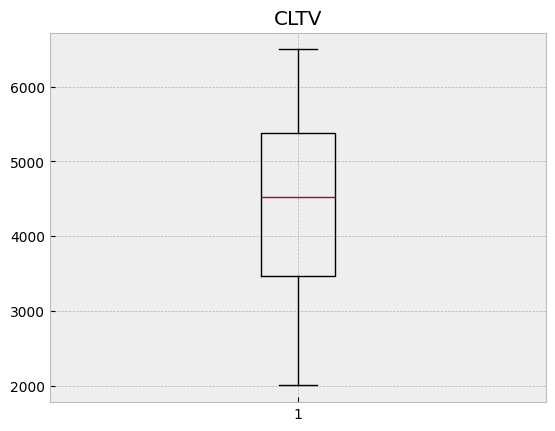

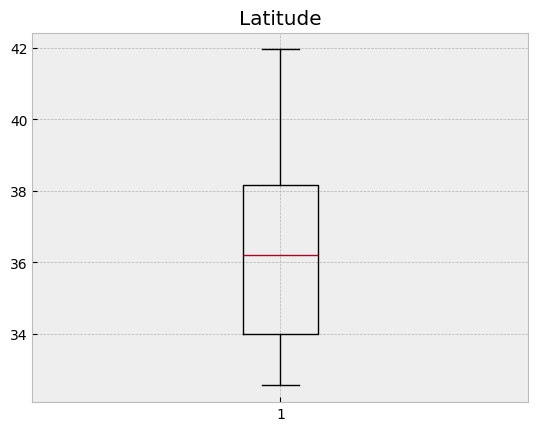

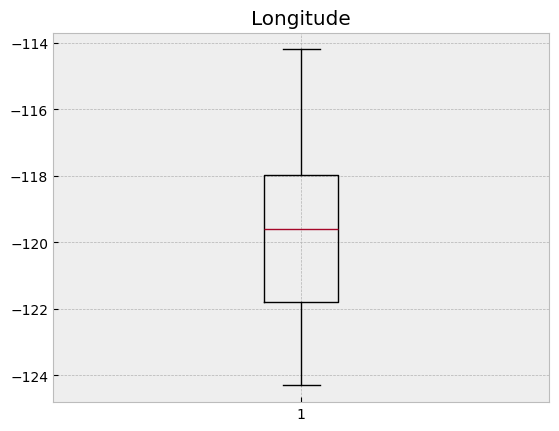

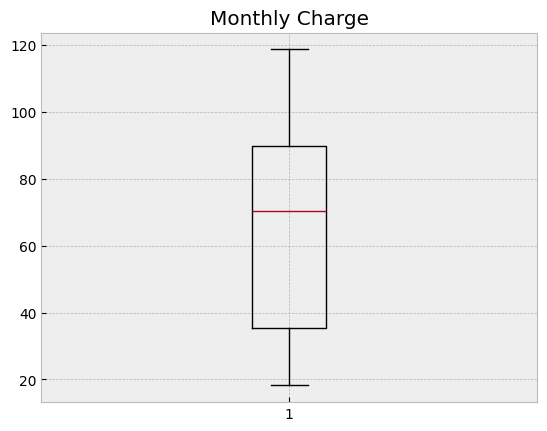

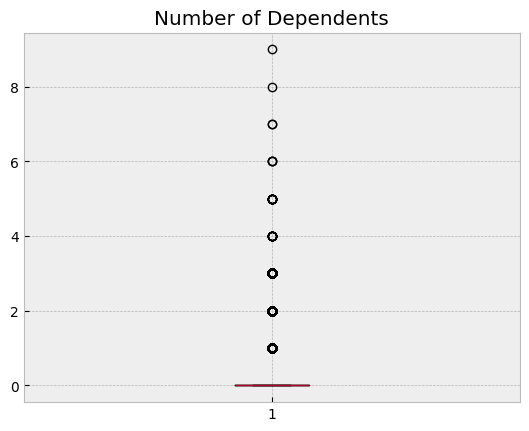

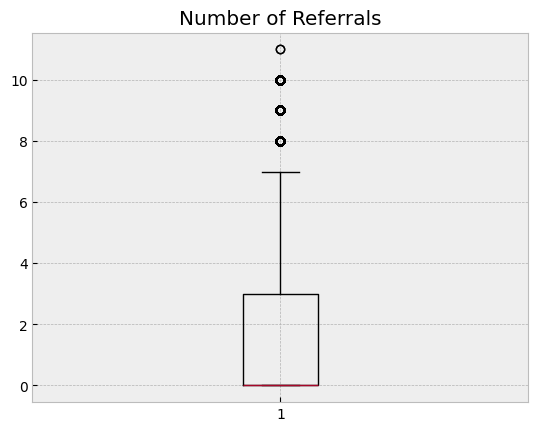

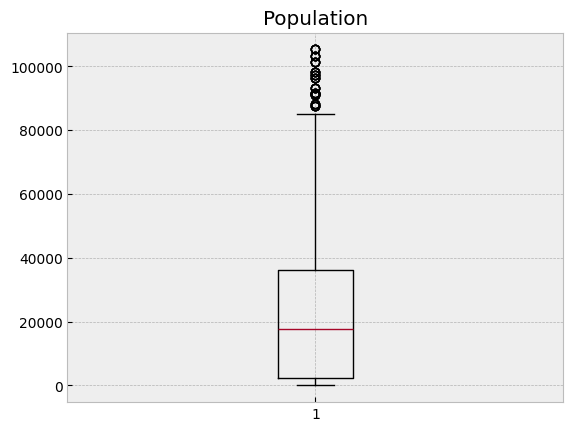

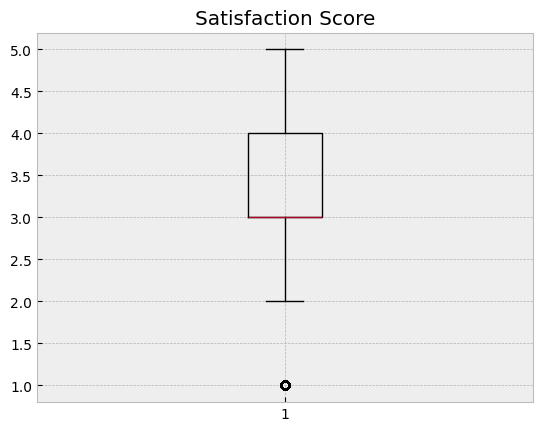

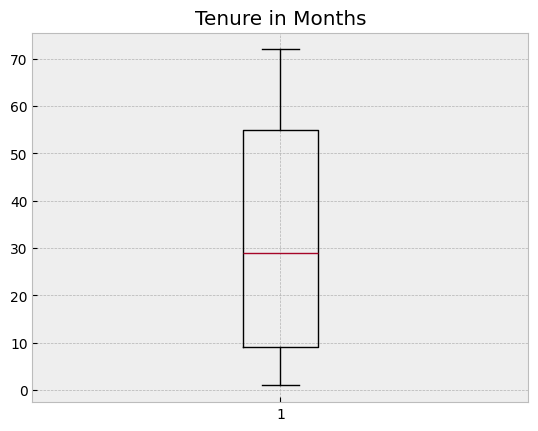

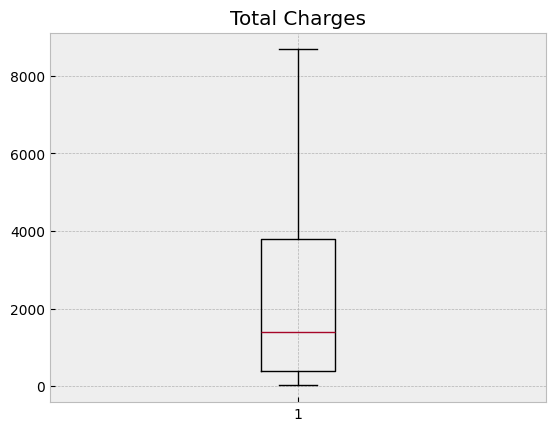

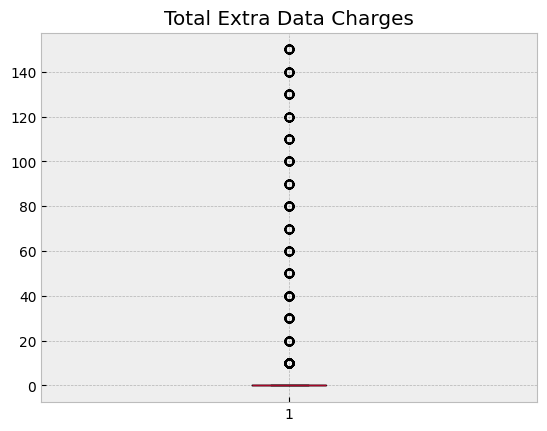

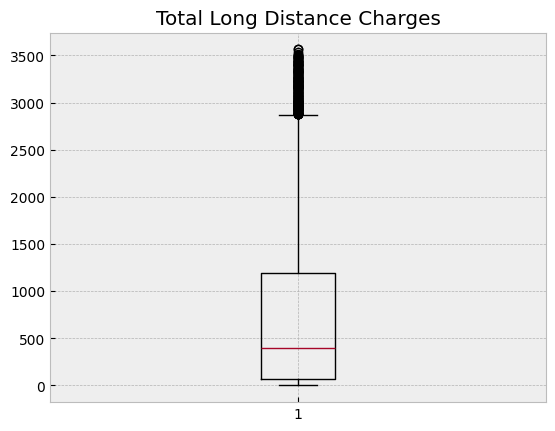

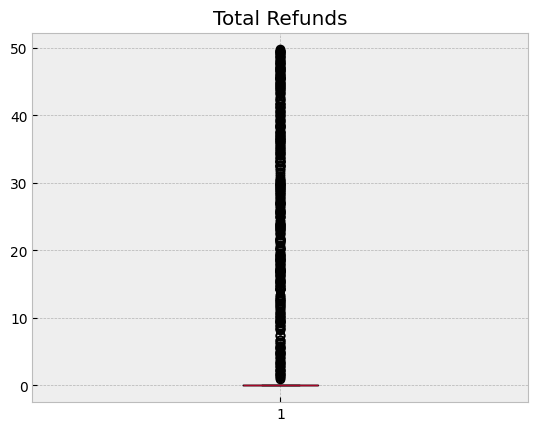

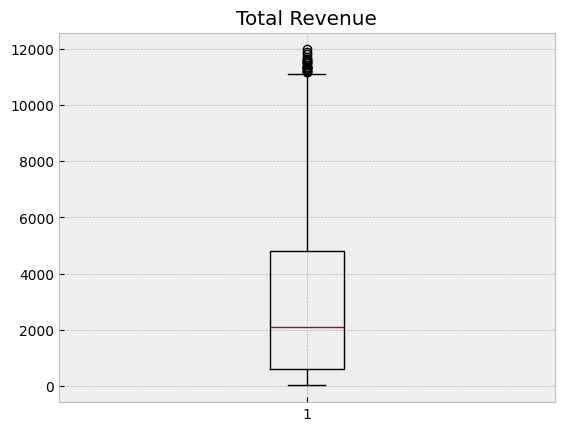

In [16]:
#Boxplot por variable
for col in num:
    fig, ax = plt.subplots()
    ax.boxplot(df[col].dropna())
    ax.set_title(col)
    plt.show()

Los boxplots confirman la presencia de valores extremos.
Estos no parecen errores, sino clientes con alto consumo acumulado.

Las variables Number of Dependents, Number of Referrals, Total Charges, Total Extra Data Charges, Total Long Distance Charges, Total Refunds y Total Revenue presentan una distribución fuertemente sesgada debido a la presencia de valores elevados en un subconjunto reducido de clientes.

Esta cola larga puede introducir distorsiones en determinados modelos predictivos, por lo que resulta necesario analizarlas en detalle y aplicar los tratamientos oportunos durante la fase de Preprocessing.

Al revisar las variables numéricas mediante boxplots y análisis de percentiles, se observan valores altos que podrían considerarse outliers según criterios estadísticos (IQR). Sin embargo, estos valores son consistentes con la naturaleza del negocio: corresponden a clientes con altos consumos o facturación acumulada, por lo que se consideran esperables y no se eliminan.

In [17]:
def detectar_outliers_iqr(df, columnas):
    outlier_info = {}

    for col in columnas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)][col]
        outlier_info[col] = len(outliers)

    return outlier_info

outliers_detectados = detectar_outliers_iqr(df, num)
outliers_detectados


{'Age': 0,
 'Avg Monthly GB Download': 362,
 'Avg Monthly Long Distance Charges': 0,
 'Churn Score': 0,
 'CLTV': 0,
 'Latitude': 0,
 'Longitude': 0,
 'Monthly Charge': 0,
 'Number of Dependents': 1627,
 'Number of Referrals': 676,
 'Population': 57,
 'Satisfaction Score': 922,
 'Tenure in Months': 0,
 'Total Charges': 0,
 'Total Extra Data Charges': 728,
 'Total Long Distance Charges': 196,
 'Total Refunds': 525,
 'Total Revenue': 21}

#### Exploración de variables con alta asimetría

En esa sección se realiza un análisis univariado de las variables numéricas que presentan distribuciones muy sesgadas, con el objetivo de:

*   Detectar asimetrías y valores extremos (outliers).
*   Identificar posibles transformaciones necesarias (por ejemplo, logaritmos o normalización) para que los modelos funcionen mejor.
*   Comprender la dispersión y concentración de los datos antes de aplicar técnicas multivariadas o de modelado.

In [18]:
#Exploración de la variable Number of Dependents
df["Number of Dependents"].value_counts().sort_index()

Number of Dependents
0    5416
1     553
2     531
3     517
4       9
5      10
6       3
7       2
8       1
9       1
Name: count, dtype: int64

La mayoría de los clientes tiene pocos o ningún dependiente,
con una frecuencia decreciente a medida que aumenta el número.

In [19]:
#Exploración de la variable Number of Referrals
df["Number of Referrals"].value_counts().sort_index()

Number of Referrals
0     3821
1     1086
2      236
3      255
4      236
5      264
6      221
7      248
8      213
9      238
10     223
11       2
Name: count, dtype: int64

Se observa una fuerte concentración en cero referencias,
con pocos clientes generando múltiples referidos.


In [20]:
#Exploración de la variable Total Extra Data Charges
zero_count_TEDC = (df['Total Extra Data Charges'] == 0).sum()
non_zero_count_TEDC = len(df) - zero_count_TEDC
greater_than_50_count_TEDC = (df['Total Extra Data Charges'] > 50).sum()
fewer_than_50_count_TEDC = non_zero_count_TEDC - greater_than_50_count_TEDC
print(f"Cantidad de clientes que no tienen cargos totales extra de datos: {zero_count_TEDC}")
print(f"Cantidad de clientes que tienen cargos totales extra de datos: {non_zero_count_TEDC}")
print(f"Cantidad de clientes que tienen cargos totales extra de datos superiores a 50$: {greater_than_50_count_TEDC}")
print(f"Cantidad de clientes que tienen cargos totales extra de datos, y son inferiores a 50$: {fewer_than_50_count_TEDC}")

Cantidad de clientes que no tienen cargos totales extra de datos: 6315
Cantidad de clientes que tienen cargos totales extra de datos: 728
Cantidad de clientes que tienen cargos totales extra de datos superiores a 50$: 376
Cantidad de clientes que tienen cargos totales extra de datos, y son inferiores a 50$: 352


La mayoría de los clientes no tiene cargos extra de datos,
mientras que un subconjunto reducido concentra los valores más altos.


In [21]:
#Exploración de la variable Total Refunds
df["Total Refunds"].value_counts().sort_index()

Total Refunds
0.00     6518
1.01        1
1.09        1
1.27        1
1.31        2
         ... 
49.51       1
49.53       1
49.57       2
49.76       1
49.79       1
Name: count, Length: 500, dtype: int64

Se observa una fuerte concentración en cero referencias, con una minoría de clientes con devoluciones.

#### Distribución de variables categóricas y binarias

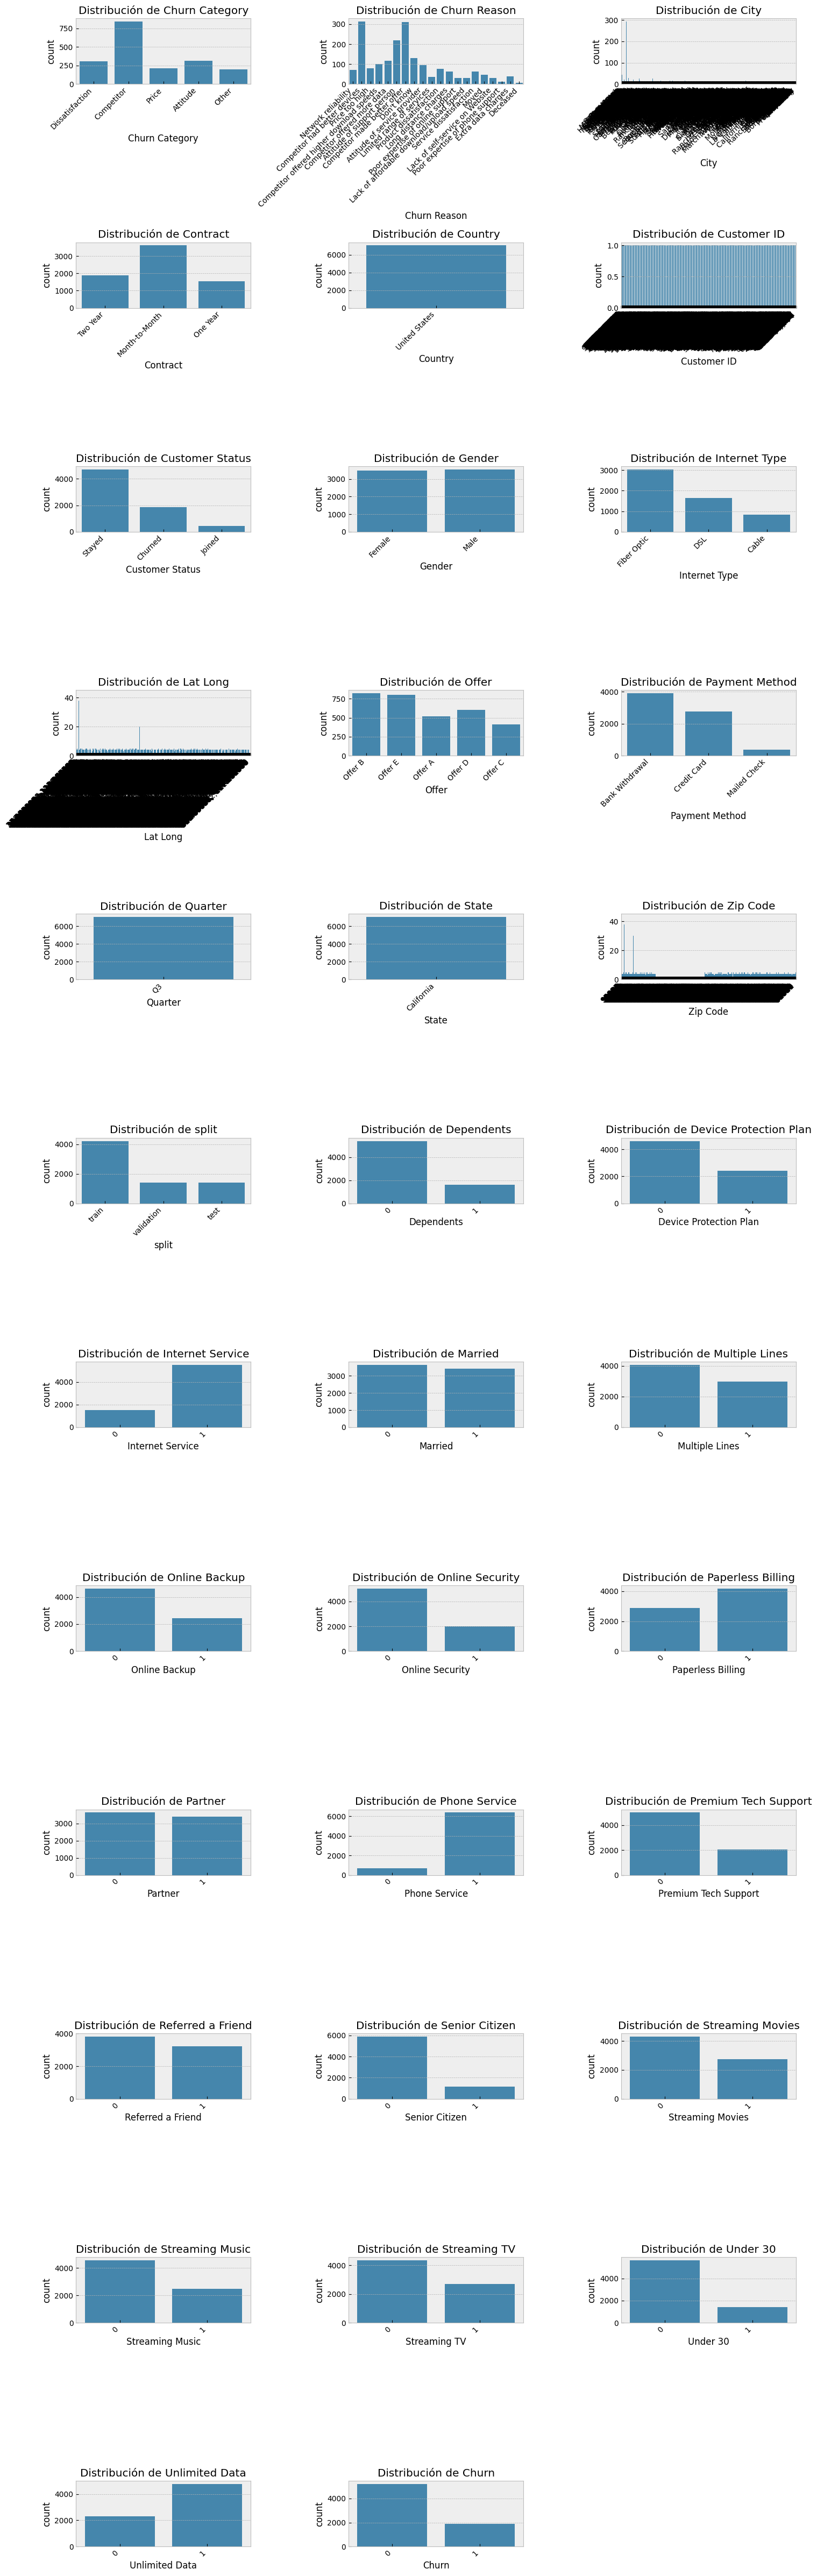

In [22]:
#Distribución variables categóricas y binarias
num_plots = len(cat_and_binary_raw )
num_cols = 3 # Número de filas en la cuadrícula
num_rows = (num_plots + num_cols - 1) // num_cols # Calcula las filas necesarias

plt.figure(figsize=(num_cols * 5, num_rows * 4)) # Para ajustar el tamaño de la figura

for i, col in enumerate(cat_and_binary_raw ):
    plt.subplot(num_rows, num_cols, i + 1) # Crea subplots
    sns.countplot(x=df[col])
    plt.title(f"Distribución de {col}")
    plt.xticks(rotation=45, ha='right') # Rota las etiquetas para mejorar la legibilidad

plt.tight_layout() # Ajustar el diseño para evitar que las etiquetas se superpongan
plt.show()

Algunas variables categóricas, como Gender, Married y Partner, presentan una distribución casi equilibrada entre sus valores (aproximadamente 50-50). Decidimos evaluarlas mediante tablas cruzadas y proporciones frente al target, ya que, aunque su balance podría indicar poca influencia, es importante confirmar si aportan información relevante para la predicción antes de decidir mantenerlas o eliminarlas.

#### Relación con el target: tablas cruzadas

Analizaremos cómo las variables categóricas Gender, Married y Partner se relacionan con la variable objetivo (Streaming Movies). Esto se hace mediante tablas de contingencia que muestran la distribución de los valores de cada variable en función de si el cliente contrata o no el servicio de streaming.

In [23]:
#Tabla cruzada o de contingencia de Streaming Movies y Gender
pd.crosstab(df['Gender'], df['Streaming Movies'], normalize='index')

Streaming Movies,0,1
Gender,,
Female,0.606938,0.393062
Male,0.617159,0.382841


Las proporciones son muy similares entre Female y Male (diferencia <1%).

Por los que Gender no aporta información relevante para discriminar el target y no se incluirá en el modelo.

In [24]:
#Tabla cruzada o de contingencia de Streaming Movies y Married
pd.crosstab(df['Married'], df['Streaming Movies'], normalize='index')


Streaming Movies,0,1
Married,,
0,0.667399,0.332601
1,0.552910,0.447090


In [25]:
#Tabla cruzada o de contingencia de Streaming Movies y Partner
pd.crosstab(df['Partner'], df['Streaming Movies'], normalize='index')

Streaming Movies,0,1
Partner,,
0,0.667399,0.332601
1,0.552910,0.447090


Observamos que las variables Married y Partner muestran exactamente las mismas proporciones frente al target, lo que sugiere que incluyen la misma información. Aunque Married presenta diferencias claras en la proporción de usuarios que ven streaming (44% vs 33%), Partner no aporta información adicional.

### C ) Análisis multivariado

En este apartado exploramos las relaciones entre varias variables al mismo tiempo para identificar patrones, dependencias y posibles redundancias. Utilizaremos matrices de correlación para detectar relaciones lineales entre variables numéricas.

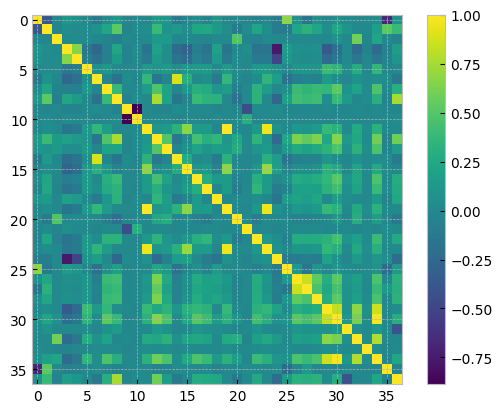

In [26]:
#Análisis multivariado - Matriz de correlación
plt.imshow(df.select_dtypes(include=np.number).corr())
plt.colorbar()
plt.show()

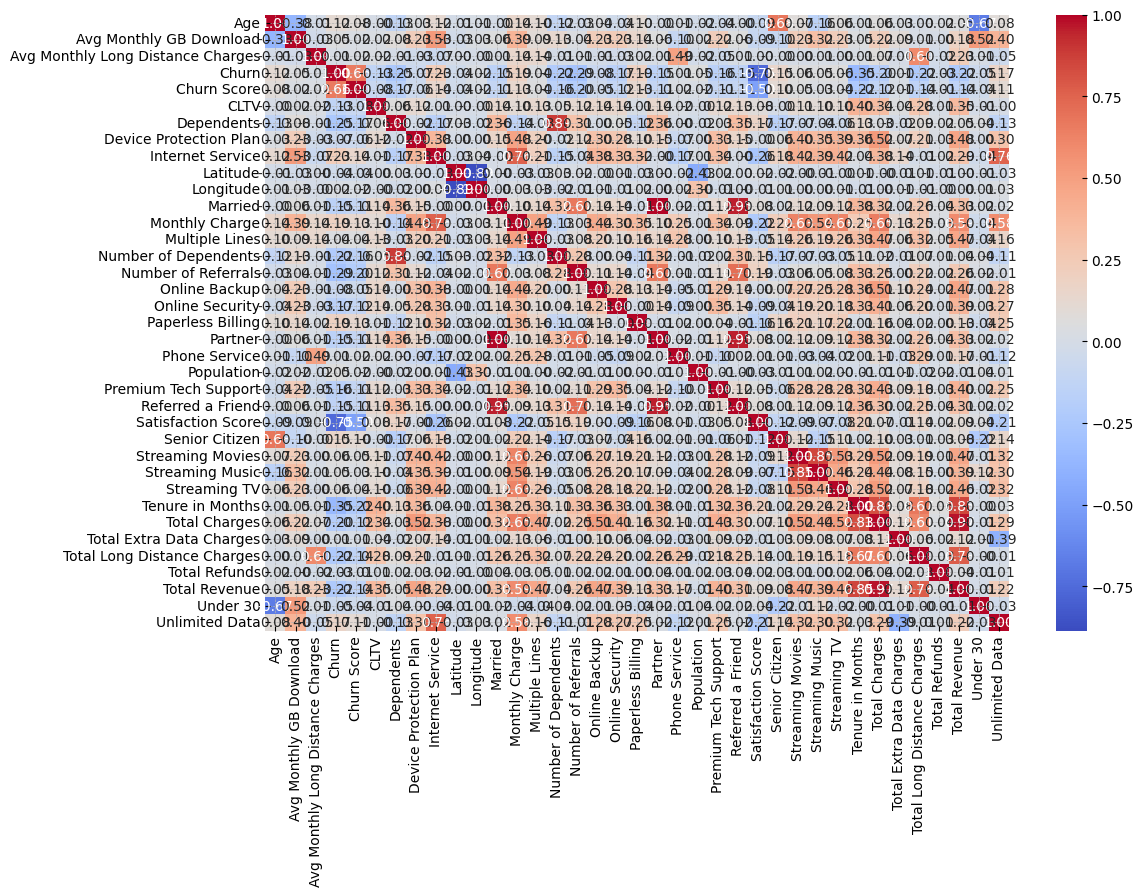

In [27]:
# Matriz de correlación numérica
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

Se identifica una correlación muy elevada entre Streaming TV y Streaming Movies,
indicando que ambas variables capturan un comportamiento muy similar.


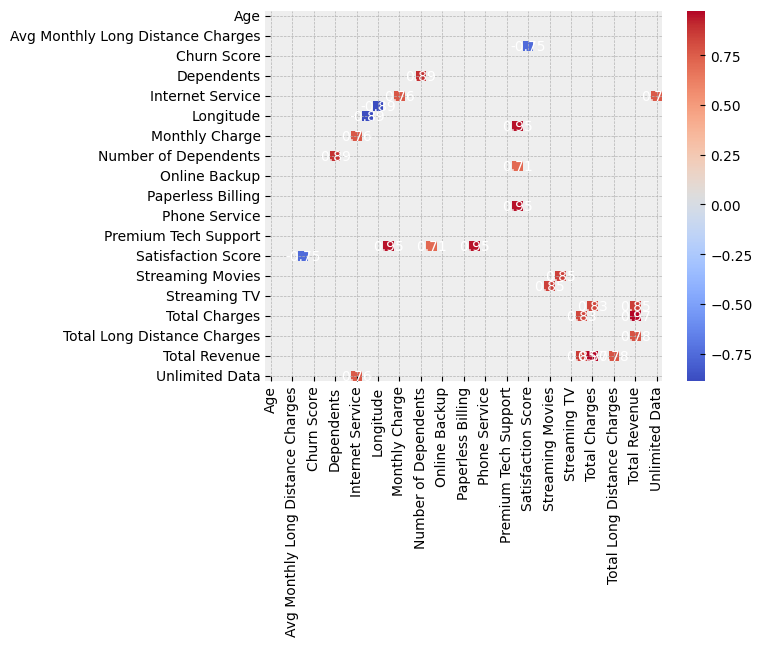

In [28]:
corr = df[num_cols].corr()
mask = (abs(corr) > 0.7) & (abs(corr) < 1.0)  # excluye la diagonal
sns.heatmap(corr[mask], annot=True, fmt=".2f", cmap='coolwarm')
plt.show()


## 1.4. Preprocessing

Antes de entrenar el modelo, realizamos una serie de pasos para preparar los datos como transformar las variables, verificar que no hay nulos, limpiar los datos y codificar las variables categóricas.

### Transformación de variables

Durante el análisis exploratorio (EDA) se observó que varias variables presentan **distribuciones sesgadas, colas largas o inflaciones de ceros**, lo que podría afectar la estabilidad y capacidad predictiva de los modelos de clasificación. Para mitigar estos efectos, se aplicaron transformaciones específicas a cada variable, combinando técnicas como **agrupación, binarización, discretización, capping y logaritmo** según la naturaleza de los datos.

| Variable                   | Motivo                             | Transformación                       |
|----------------------------|-----------------------------------|-------------------------------------|
| Number of Dependents       | Distribución concentrada en valores bajos y algunos extremos | Agrupación (0-3, 4-6, 7+)          |
| Number of Referrals        | Muchos ceros y pocos valores altos | Agrupación (0,1,2+) |
| Total Charges              | Algunos clientes con valores muy altos | Log + Escalado                       |
| Total Extra Data Charges   | Gran parte sin cargos y algunos muy altos | Discretización (no charge / Less / High) |
| Total Long Distance Charges| Valores extremos que distorsionan la distribución | Capping + Log                        |
| Total Revenue              | Valores extremos que podrían dominar el modelo | Capping + Log     


In [29]:
#Transformar variable Number of Dependents
def group_dependents(x):
    if x == 0:
        return "0"
    elif x <= 2:
        return "1-2"
    elif x <= 4:
        return "3-4"
    else:
        return "5+"

df["Number Dependents Grouped"] = df["Number of Dependents"].apply(group_dependents)

In [30]:
#Transformar variable Number of Referrals
def group_referrals(x):
    if x == 0:
        return "0"
    elif x == 1:
        return "1"
    else:
        return "2+"

df["Referrals Grouped"] = df["Number of Referrals"].apply(group_referrals)

In [31]:
#Transformación logarítmica y escalado: Total Charges Log
df["Total Charges Log"] = np.log1p(df["Total Charges"])

In [32]:
#Transformar Total Extra Data Charges
def categorize_extra_data_charges(x):
    if x == 0:
        return "no charge"
    elif x > 50:
        return "High"
    else:
        return "Less"

df["Total Extra Data Charges Category"] = df["Total Extra Data Charges"].apply(categorize_extra_data_charges)


In [33]:
df["Total Extra Data Charges Category"].value_counts()


Total Extra Data Charges Category
no charge    6315
High          376
Less          352
Name: count, dtype: int64

In [34]:
#Capping + transformación logarítmica: Total Long Distance Charges
upper_cap = df["Total Long Distance Charges"].quantile(0.95)
df["Total Long Distance Charges Capped"] = df["Total Long Distance Charges"].clip(upper=upper_cap)
df["Total Long Distance Charges Log"] = np.log1p(df["Total Long Distance Charges Capped"])

In [35]:
#Capping + log + escalado Total Revenue
upper_cap = df["Total Revenue"].quantile(0.95)
df["Total Revenue Capped"] = df["Total Revenue"].clip(upper=upper_cap)
df["Total Revenue Log"] = np.log1p(df["Total Revenue Capped"])

In [36]:
#Visualización de los datos con las nuevas variables
df.head(5)

,Age,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Churn,Churn Category,Churn Reason,Churn Score,City,CLTV,Contract,Country,Customer ID,Customer Status,Dependents,Device Protection Plan,Gender,Internet Service,Internet Type,Lat Long,Latitude,Longitude,Married,Monthly Charge,Multiple Lines,Number of Dependents,Number of Referrals,Offer,Online Backup,Online Security,Paperless Billing,Partner,Payment Method,Phone Service,Population,Premium Tech Support,Quarter,Referred a Friend,Satisfaction Score,Senior Citizen,State,Streaming Movies,Streaming Music,Streaming TV,Tenure in Months,Total Charges,Total Extra Data Charges,Total Long Distance Charges,Total Refunds,Total Revenue,Under 30,Unlimited Data,Zip Code,split,Number Dependents Grouped,Referrals Grouped,Total Charges Log,Total Extra Data Charges Category,Total Long Distance Charges Capped,Total Long Distance Charges Log,Total Revenue Capped,Total Revenue Log
0,72,4,19.44,0,None,None,51,San Mateo,4849,Two Year,United States,4526-ZJJTM,Stayed,0,1,Female,1,Fiber Optic,"37.538309, -122.305109",37.538309,-122.305109,1,88.40,0,0,1,None,1,0,0,1,Bank Withdrawal,1,37926,0,Q3,1,3,1,California,1,1,0,25,2191.15,0,486.00,0.0,2677.15,0,1,94403,train,0,1,7.692638,no charge,486.00,6.188264,2677.15,7.892882
1,27,59,45.62,0,None,None,27,Sutter Creek,3715,Month-to-Month,United States,5302-BDJNT,Stayed,0,1,Male,1,Fiber Optic,"38.432145, -120.77069",38.432145,-120.770690,0,95.50,1,0,0,None,0,0,0,0,Bank Withdrawal,1,4610,1,Q3,0,3,0,California,0,0,1,35,3418.20,0,1596.70,0.0,5014.90,1,1,95685,train,0,0,8.137162,no charge,1596.70,7.376320,5014.90,8.520368
2,59,0,16.07,0,None,None,59,Santa Cruz,5092,Month-to-Month,United States,5468-BPMMO,Stayed,0,0,Male,0,None,"37.007882, -122.065975",37.007882,-122.065975,1,19.60,0,0,3,None,0,0,0,1,Bank Withdrawal,1,4563,0,Q3,1,5,0,California,0,0,0,46,851.20,0,739.22,0.0,1590.42,0,0,95064,train,0,2+,6.747821,no charge,739.22,6.606947,1590.42,7.372382
3,25,27,0.00,0,None,None,49,Brea,2068,One Year,United States,2212-LYASK,Stayed,0,1,Male,1,DSL,"33.924143, -117.79387",33.924143,-117.793870,1,45.85,0,0,3,None,1,0,1,1,Credit Card,0,1408,0,Q3,1,4,0,California,1,1,0,27,1246.40,30,0.00,0.0,1276.40,1,0,92823,train,0,2+,7.128817,Less,0.00,0.000000,1276.40,7.152582
4,31,21,17.22,1,Dissatisfaction,Network reliability,88,San Jose,4026,One Year,United States,0378-XSZPU,Churned,0,1,Male,1,Cable,"37.311088, -121.961786",37.311088,-121.961786,1,60.30,0,0,1,Offer B,1,1,0,1,Credit Card,1,29914,0,Q3,1,2,0,California,0,0,0,58,3563.80,0,998.76,0.0,4562.56,0,1,95117,train,0,1,8.178863,no charge,998.76,6.907515,4562.56,8.425858


### Limpieza de los datos

Antes de modelar, realizamos una revisión y limpieza exhaustiva del dataset para asegurar que los datos sean consistentes y adecuados para el aprendizaje automático.

| Variable                            | Motivo                                                                                                              |
| ----------------------------------- | ------------------------------------------------------------------------------------------------------------------- |
| **Customer ID**                     | Identificador único. No aporta información sobre el target y no tiene poder predictivo.                             |
| **Country**                         | Toda la muestra es EEUU, sin variabilidad.                                                                          |
| **State**                           | Toda la muestra es California, no aporta información adicional.                                                     |
| **City**                            | Redundante con State; todas las ciudades están en el mismo estado.                                                  |
| **Latitude / Longitude / Lat Long** | Sin variación geográfica significativa; no aporta información útil para la predicción.                              |
| **Quarter**                         | Baja relevancia predictiva y no se realiza análisis estacional en este proyecto.                                    |
| **Churn Category**                  | Muchos valores faltantes y redundante con Churn; se elimina para evitar data leakage.                               |
| **Churn Reason**                    | Muchos valores faltantes y redundante; no aporta valor adicional.                                                   |
| **Churn Score**                     | Derivada de Churn, riesgo de data leakage; ya contamos con Churn.                                                   |
| **Zip Code**                        | Alta cardinalidad y parecido a un ID; no aporta valor predictivo y complica el modelo.                              |
| **Population**                      | Poca variabilidad geográfica, no aporta señal relevante.                                                            |
| **Offer**                           | Variable histórica de marketing; riesgo de data leakage y no refleja propensión futura.                             |
| **Age**                             | Redundante con Under 30; se elimina para simplificar el modelo.                                                     |
| **Senior Citizen**                  | Redundante con Age / Under 30; se elimina para simplificar.                                                         |
| **Number of Dependents**            | Baja relevancia y poca variabilidad; no aporta información útil.                                                    |
| **Number of Referrals**             | Se reemplaza por `Referrals Grouped` para simplificar y evitar variables redundantes; facilita análisis categórico. |
| **Partner**                         | Redundante con `Married`; contiene la misma información y se elimina para simplificar.                              |
| **Total Refunds**                   | Mayormente ceros; no aporta señal predictiva.                                                                       |
| **Total Extra Data Charges**        | Baja variabilidad; poca contribución al modelo.                                                                     |
| **Total Long Distance Charges**     | Baja variabilidad; no aporta información relevante.                                                                 |
| **Total Revenue**                   | Variable muy agregada; podría derivarse de otras columnas.                                                          |
| **Total Charges**                   | Variable muy agregada y correlacionada con otras métricas; no aporta información independiente.                     |
| **Internet Type**                   | Muchos NaN asociados a usuarios sin Internet Service; no aporta valor adicional.                                    |
| **Internet Type**                   | Columna de train y test del dataset original.                                    |

In [ ]:
# Lista de columnas a eliminar con justificación clara y narrativa
cols_to_drop = [
    'Customer ID',                # Identificador único; no aporta información sobre el target
    'Country',                    # Toda la muestra es EEUU; sin variabilidad
    'State',                      # Toda la muestra es California; sin variabilidad
    'City',                       # Redundante con State; todas las ciudades en el mismo estado
    'Latitude',                    # Sin variación geográfica significativa
    'Longitude',                   # Sin variación geográfica significativa
    'Lat Long',                   # Redundante con Latitude/Longitude
    'Quarter',                    # Baja relevancia predictiva; no se realiza análisis estacional
    'Churn Category',             # Muchos NaN y redundante con Churn; riesgo de data leakage
    'Churn Reason',               # Muchos NaN y redundante; no aporta información adicional
    'Churn Score',                # Derivada de Churn; riesgo de data leakage
    'Zip Code',                   # Alta cardinalidad; parecido a un ID, poco útil
    'Population',                 # Poca variabilidad geográfica; no aporta señal relevante
    'Offer',                      # Variable histórica de marketing; riesgo de data leakage
    'Age',                        # Redundante con Under 30; se elimina para simplificar
    'Senior Citizen',             # Redundante con Age / Under 30
    'Number of Dependents',       # Baja relevancia; poca variabilidad
    'Number of Referrals',        # Se reemplaza por Referrals Grouped; evita redundancia
    'Partner',                    # Redundante con Married; contiene la misma información
    'Total Refunds',              # Mayormente ceros; poca información útil
    'Total Charges',              # Variable agregada; muy correlacionada con otras métricas
    'Total Extra Data Charges',   # Baja variabilidad; aporta poco al modelo
    'Total Long Distance Charges',# Baja variabilidad; poco relevante
    'Total Revenue',              #Tras el entrenamiento inicial, se detectó que esta variable generaba target leakage al revelar implícitamente la contratación a través del importe de la factura.
    'Internet Type',              # Muchos NaN asociados a usuarios sin Internet Service; poco útil
    'split',                      #Columna de train y test del dataset original
    'Monthly Charge',             #Tras el entrenamiento inicial, se detectó que esta variable generaba target leakage al revelar implícitamente la contratación a través del importe de la factura.
    'Streaming Music'             #Tras el entrenamiento inicial, se detectó que esta variable tenía una excesiva dominancia que ocultaba otros patrones relevantes.
]

# Filtrar solo columnas existentes para evitar errores
cols_to_drop = [col for col in cols_to_drop if col in df.columns]

# Eliminar columnas
df = df.drop(columns=cols_to_drop)

# Revisar el resultado
print("Columnas eliminadas:", cols_to_drop)
print("Columnas restantes:", df.columns.tolist())

Columnas eliminadas: ['Customer ID', 'Country', 'State', 'City', 'Latitude', 'Longitude', 'Lat Long', 'Quarter', 'Churn Category', 'Churn Reason', 'Churn Score', 'Zip Code', 'Population', 'Offer', 'Age', 'Senior Citizen', 'Number of Dependents', 'Number of Referrals', 'Partner', 'Total Refunds', 'Total Charges', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Internet Type', 'split', 'Monthly Charge', 'Streaming Music']
Columnas restantes: ['Avg Monthly GB Download', 'Avg Monthly Long Distance Charges', 'Churn', 'CLTV', 'Contract', 'Customer Status', 'Dependents', 'Device Protection Plan', 'Gender', 'Internet Service', 'Married', 'Multiple Lines', 'Online Backup', 'Online Security', 'Paperless Billing', 'Payment Method', 'Phone Service', 'Premium Tech Support', 'Referred a Friend', 'Satisfaction Score', 'Streaming Movies', 'Streaming TV', 'Tenure in Months', 'Under 30', 'Unlimited Data', 'Number Dependents Grouped', 'Referrals Grouped', 'Total Charges Log',

In [38]:
df

,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Churn,CLTV,Contract,Customer Status,Dependents,Device Protection Plan,Gender,Internet Service,Married,Multiple Lines,Online Backup,Online Security,Paperless Billing,Payment Method,Phone Service,Premium Tech Support,Referred a Friend,Satisfaction Score,Streaming Movies,Streaming TV,Tenure in Months,Under 30,Unlimited Data,Number Dependents Grouped,Referrals Grouped,Total Charges Log,Total Extra Data Charges Category,Total Long Distance Charges Capped,Total Long Distance Charges Log,Total Revenue Capped,Total Revenue Log
0,4,19.44,0,4849,Two Year,Stayed,0,1,Female,1,1,0,1,0,0,Bank Withdrawal,1,0,1,3,1,0,25,0,1,0,1,7.692638,no charge,486.00,6.188264,2677.150,7.892882
1,59,45.62,0,3715,Month-to-Month,Stayed,0,1,Male,1,0,1,0,0,0,Bank Withdrawal,1,1,0,3,0,1,35,1,1,0,0,8.137162,no charge,1596.70,7.376320,5014.900,8.520368
2,0,16.07,0,5092,Month-to-Month,Stayed,0,0,Male,0,1,0,0,0,0,Bank Withdrawal,1,0,1,5,0,0,46,0,0,0,2+,6.747821,no charge,739.22,6.606947,1590.420,7.372382
3,27,0.00,0,2068,One Year,Stayed,0,1,Male,1,1,0,1,0,1,Credit Card,0,0,1,4,1,0,27,1,0,0,2+,7.128817,Less,0.00,0.000000,1276.400,7.152582
4,21,17.22,1,4026,One Year,Churned,0,1,Male,1,1,0,1,1,0,Credit Card,1,0,1,2,0,0,58,0,1,0,1,8.178863,no charge,998.76,6.907515,4562.560,8.425858
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,12,10.67,0,4847,Month-to-Month,Stayed,0,1,Female,1,0,1,0,0,0,Bank Withdrawal,1,0,0,4,1,1,29,0,1,0,0,7.965459,no charge,309.43,5.737958,3188.180,8.067519
7039,30,30.44,0,5470,Two Year,Stayed,0,1,Female,1,0,0,0,0,0,Bank Withdrawal,1,0,0,3,1,1,59,0,1,0,0,8.640552,no charge,1795.96,7.493852,7451.410,8.916293
7040,24,4.51,0,4471,Two Year,Stayed,0,1,Female,1,0,1,0,1,0,Credit Card,1,1,0,4,1,1,61,0,1,0,0,8.551846,no charge,275.11,5.620799,5450.410,8.603630
7041,24,47.06,0,5445,Two Year,Stayed,0,1,Male,1,0,0,0,1,1,Mailed Check,1,0,0,3,0,0,30,0,1,0,0,7.411466,no charge,1411.80,7.253329,3065.650,8.028341


### Codificación variables categóricas

Para poder usar correctamente las variables categóricas en modelos de aprendizaje automático, es necesario transformarlas a formato numérico.

El método elegido fue One Hot Encoding, que crea una columna binaria por cada categoría de la variable. Cada fila tendrá un 1 en la columna correspondiente a su categoría y 0 en las demás.

| Variable                                    | Valor  | Variable original                 |
| ------------------------------------------- | ------ | --------------------------------- |
| contract_One Year                           | (0, 1) | Contract                          |
| contract_Two Year                           | (0, 1) | Contract                          |
| customer_status_Churned                     | (0, 1) | Customer Status                   |
| customer_status_Joined                      | (0, 1) | Customer Status                   |
| gender_Male                                 | (0, 1) | Gender                            |
| payment_method_Credit Card                  | (0, 1) | Payment Method                    |
| payment_method_Mailed Check                 | (0, 1) | Payment Method                    |
| number_dependents_grouped_0                 | (0, 1) | Number Dependents Grouped         |
| number_dependents_grouped_1-2               | (0, 1) | Number Dependents Grouped         |
| number_dependents_grouped_3-4               | (0, 1) | Number Dependents Grouped         |
| number_dependents_grouped_5+                | (0, 1) | Number Dependents Grouped         |
| referrals_grouped_0                         | (0, 1) | Referrals Grouped                 |
| referrals_grouped_1                         | (0, 1) | Referrals Grouped                 |
| referrals_grouped_2+                        | (0, 1) | Referrals Grouped                 |
| total_extra_data_charges_category_no charge | (0, 1) | Total Extra Data Charges Category |
| total_extra_data_charges_category_Less      | (0, 1) | Total Extra Data Charges Category |
| total_extra_data_charges_category_High      | (0, 1) | Total Extra Data Charges Category |

In [39]:
# 1. Regenerar variables categóricas (object)
cat_vars = df.select_dtypes(include="object").columns.tolist()

# 2. Regenerar variables binarias (0/1 reales)
binary_vars = [
    col for col in df.columns
    if df[col].dtype in ['int64', 'int32'] and df[col].nunique() == 2
]

# 3. Seleccionar solo multiclase (categorías con >2 niveles)
cat_multiclass = [
    col for col in cat_vars
    if col not in binary_vars
]

print("Categóricas multiclase:", cat_multiclass)
print("Binarias:", binary_vars)
print("Categóricas:", cat_vars)

Categóricas multiclase: ['Contract', 'Customer Status', 'Gender', 'Payment Method', 'Number Dependents Grouped', 'Referrals Grouped', 'Total Extra Data Charges Category']
Binarias: ['Churn', 'Dependents', 'Device Protection Plan', 'Internet Service', 'Married', 'Multiple Lines', 'Online Backup', 'Online Security', 'Paperless Billing', 'Phone Service', 'Premium Tech Support', 'Referred a Friend', 'Streaming Movies', 'Streaming TV', 'Under 30', 'Unlimited Data']
Categóricas: ['Contract', 'Customer Status', 'Gender', 'Payment Method', 'Number Dependents Grouped', 'Referrals Grouped', 'Total Extra Data Charges Category']


In [40]:
#Codificación de variables categóricas multiclase con One-Hot Encoding
cat_multiclass = [
    col for col in df.select_dtypes(include="object").columns
    if col not in binary_vars
]

df = pd.get_dummies(df, columns=cat_multiclass, drop_first=True)
df = df.astype({col: int for col in df.columns if df[col].dtype == "bool"})  # Convertir booleanos a enteros

In [41]:
df

,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Churn,CLTV,Dependents,Device Protection Plan,Internet Service,Married,Multiple Lines,Online Backup,Online Security,Paperless Billing,Phone Service,Premium Tech Support,Referred a Friend,Satisfaction Score,Streaming Movies,Streaming TV,Tenure in Months,Under 30,Unlimited Data,Total Charges Log,Total Long Distance Charges Capped,Total Long Distance Charges Log,Total Revenue Capped,Total Revenue Log,Contract_One Year,Contract_Two Year,Customer Status_Joined,Customer Status_Stayed,Gender_Male,Payment Method_Credit Card,Payment Method_Mailed Check,Number Dependents Grouped_1-2,Number Dependents Grouped_3-4,Number Dependents Grouped_5+,Referrals Grouped_1,Referrals Grouped_2+,Total Extra Data Charges Category_Less,Total Extra Data Charges Category_no charge
0,4,19.44,0,4849,0,1,1,1,0,1,0,0,1,0,1,3,1,0,25,0,1,7.692638,486.00,6.188264,2677.150,7.892882,0,1,0,1,0,0,0,0,0,0,1,0,0,1
1,59,45.62,0,3715,0,1,1,0,1,0,0,0,1,1,0,3,0,1,35,1,1,8.137162,1596.70,7.376320,5014.900,8.520368,0,0,0,1,1,0,0,0,0,0,0,0,0,1
2,0,16.07,0,5092,0,0,0,1,0,0,0,0,1,0,1,5,0,0,46,0,0,6.747821,739.22,6.606947,1590.420,7.372382,0,0,0,1,1,0,0,0,0,0,0,1,0,1
3,27,0.00,0,2068,0,1,1,1,0,1,0,1,0,0,1,4,1,0,27,1,0,7.128817,0.00,0.000000,1276.400,7.152582,1,0,0,1,1,1,0,0,0,0,0,1,1,0
4,21,17.22,1,4026,0,1,1,1,0,1,1,0,1,0,1,2,0,0,58,0,1,8.178863,998.76,6.907515,4562.560,8.425858,1,0,0,0,1,1,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,12,10.67,0,4847,0,1,1,0,1,0,0,0,1,0,0,4,1,1,29,0,1,7.965459,309.43,5.737958,3188.180,8.067519,0,0,0,1,0,0,0,0,0,0,0,0,0,1
7039,30,30.44,0,5470,0,1,1,0,0,0,0,0,1,0,0,3,1,1,59,0,1,8.640552,1795.96,7.493852,7451.410,8.916293,0,1,0,1,0,0,0,0,0,0,0,0,0,1
7040,24,4.51,0,4471,0,1,1,0,1,0,1,0,1,1,0,4,1,1,61,0,1,8.551846,275.11,5.620799,5450.410,8.603630,0,1,0,1,0,1,0,0,0,0,0,0,0,1
7041,24,47.06,0,5445,0,1,1,0,0,0,1,1,1,0,0,3,0,0,30,0,1,7.411466,1411.80,7.253329,3065.650,8.028341,0,1,0,1,1,0,1,0,0,0,0,0,0,1


### Selección de los datos

Tras la limpieza y codificación de los datos, se realizó una selección de variables para el modelado mirando las correlaciones

In [42]:
#Eliminación de variables altamente correlacionadas
corr = df.corr()

to_drop = []
for col in corr.columns:
    for col2 in corr.columns:
        if col != col2 and abs(corr.loc[col, col2]) > 0.90:
            to_drop.append(col2)

to_drop = list(set(to_drop))
df = df.drop(columns=to_drop)
print("Variables eliminadas por correlación:", to_drop)

Variables eliminadas por correlación: ['Referred a Friend', 'Married', 'Total Revenue Log', 'Total Charges Log']


In [43]:
df

,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Churn,CLTV,Dependents,Device Protection Plan,Internet Service,Multiple Lines,Online Backup,Online Security,Paperless Billing,Phone Service,Premium Tech Support,Satisfaction Score,Streaming Movies,Streaming TV,Tenure in Months,Under 30,Unlimited Data,Total Long Distance Charges Capped,Total Long Distance Charges Log,Total Revenue Capped,Contract_One Year,Contract_Two Year,Customer Status_Joined,Customer Status_Stayed,Gender_Male,Payment Method_Credit Card,Payment Method_Mailed Check,Number Dependents Grouped_1-2,Number Dependents Grouped_3-4,Number Dependents Grouped_5+,Referrals Grouped_1,Referrals Grouped_2+,Total Extra Data Charges Category_Less,Total Extra Data Charges Category_no charge
0,4,19.44,0,4849,0,1,1,0,1,0,0,1,0,3,1,0,25,0,1,486.00,6.188264,2677.150,0,1,0,1,0,0,0,0,0,0,1,0,0,1
1,59,45.62,0,3715,0,1,1,1,0,0,0,1,1,3,0,1,35,1,1,1596.70,7.376320,5014.900,0,0,0,1,1,0,0,0,0,0,0,0,0,1
2,0,16.07,0,5092,0,0,0,0,0,0,0,1,0,5,0,0,46,0,0,739.22,6.606947,1590.420,0,0,0,1,1,0,0,0,0,0,0,1,0,1
3,27,0.00,0,2068,0,1,1,0,1,0,1,0,0,4,1,0,27,1,0,0.00,0.000000,1276.400,1,0,0,1,1,1,0,0,0,0,0,1,1,0
4,21,17.22,1,4026,0,1,1,0,1,1,0,1,0,2,0,0,58,0,1,998.76,6.907515,4562.560,1,0,0,0,1,1,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,12,10.67,0,4847,0,1,1,1,0,0,0,1,0,4,1,1,29,0,1,309.43,5.737958,3188.180,0,0,0,1,0,0,0,0,0,0,0,0,0,1
7039,30,30.44,0,5470,0,1,1,0,0,0,0,1,0,3,1,1,59,0,1,1795.96,7.493852,7451.410,0,1,0,1,0,0,0,0,0,0,0,0,0,1
7040,24,4.51,0,4471,0,1,1,1,0,1,0,1,1,4,1,1,61,0,1,275.11,5.620799,5450.410,0,1,0,1,0,1,0,0,0,0,0,0,0,1
7041,24,47.06,0,5445,0,1,1,0,0,1,1,1,0,3,0,0,30,0,1,1411.80,7.253329,3065.650,0,1,0,1,1,0,1,0,0,0,0,0,0,1


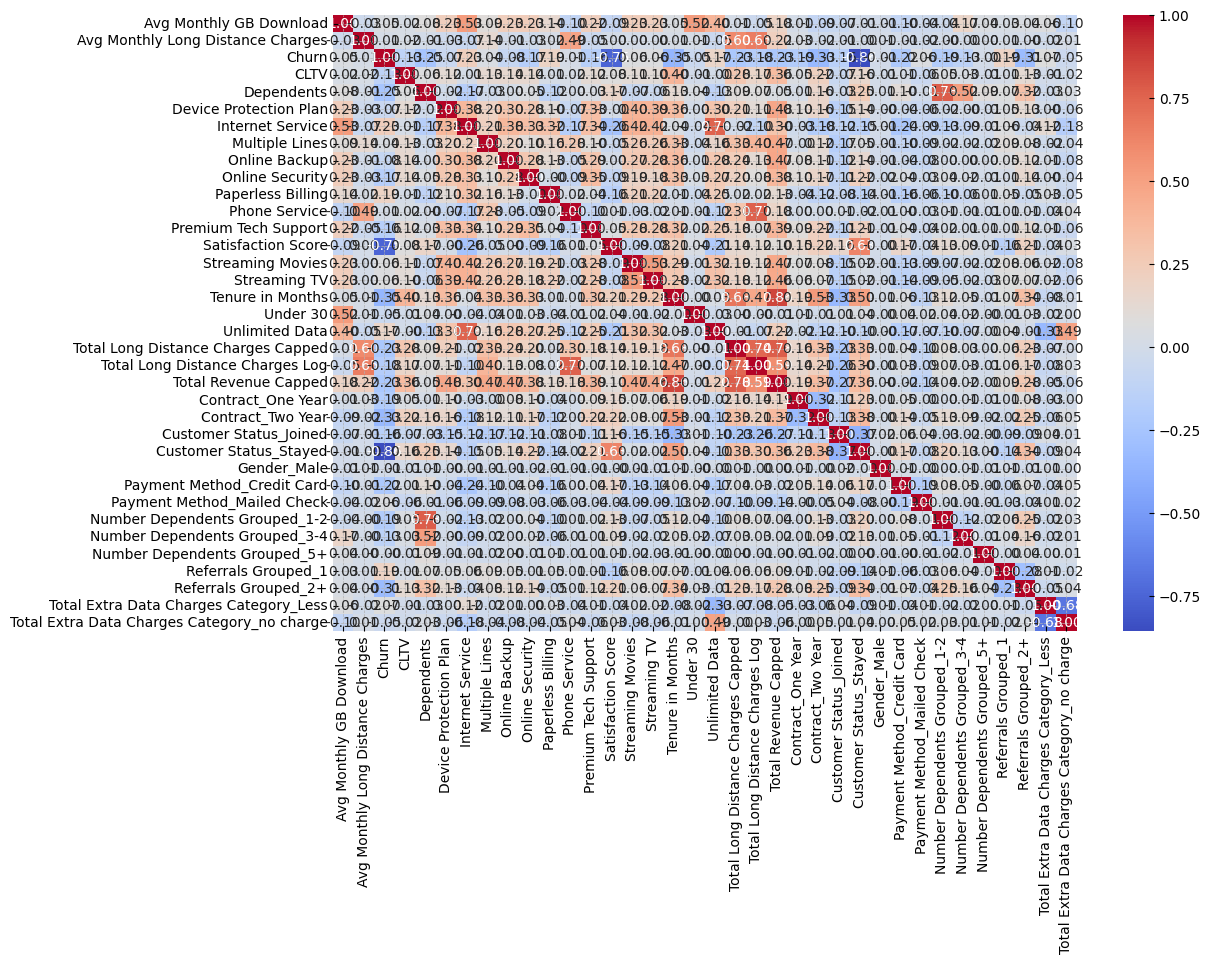

In [44]:
# Matriz de correlación numérica
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

Tras la limpieza, se analizó la matriz de correlaciones con el objetivo de identificar posibles relaciones de redundancia entre variables explicativas y el target (Streaming Movies). Se observa una correlación muy elevada entre Streaming TV y el target (r ≈ 0.88), lo que indica que ambas variables capturan prácticamente el mismo comportamiento de consumo. Dado que Streaming TV podría actuar como una proxy directa del target y sesgar el aprendizaje del modelo, se decidió eliminarla del conjunto de variables explicativas. El resto de correlaciones observadas se consideran coherentes desde un punto de vista de negocio y no implican redundancia directa, por lo que las variables se mantienen para su evaluación posterior mediante modelos predictivos.

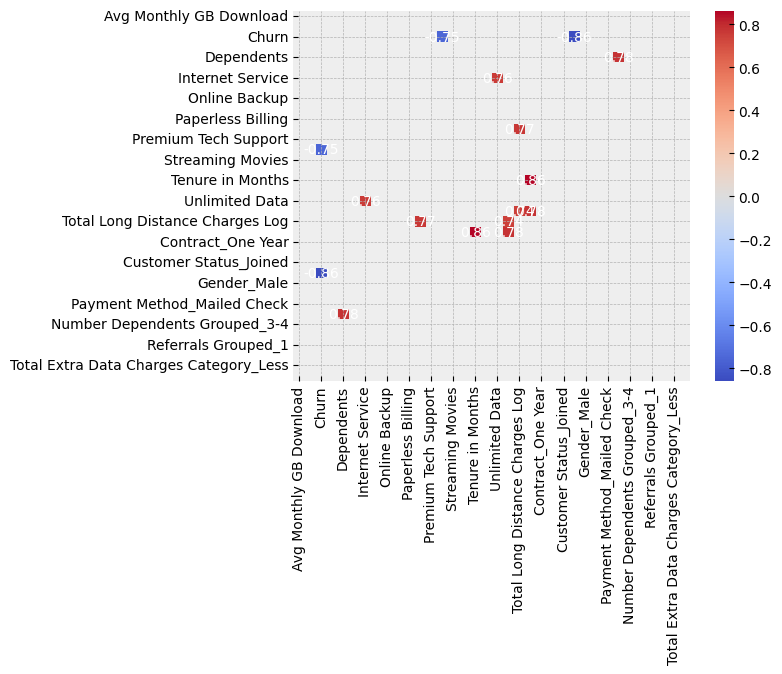

In [45]:
corr = df[num_cols].corr()
mask = (abs(corr) > 0.7) & (abs(corr) < 1.0)  # excluye la diagonal
sns.heatmap(corr[mask], annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In [46]:
# Eliminación de 'Streaming TV' por alta correlación con el target ('Streaming Movies')
df = df.drop(columns=['Streaming TV'])

In [47]:
df

,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Churn,CLTV,Dependents,Device Protection Plan,Internet Service,Multiple Lines,Online Backup,Online Security,Paperless Billing,Phone Service,Premium Tech Support,Satisfaction Score,Streaming Movies,Tenure in Months,Under 30,Unlimited Data,Total Long Distance Charges Capped,Total Long Distance Charges Log,Total Revenue Capped,Contract_One Year,Contract_Two Year,Customer Status_Joined,Customer Status_Stayed,Gender_Male,Payment Method_Credit Card,Payment Method_Mailed Check,Number Dependents Grouped_1-2,Number Dependents Grouped_3-4,Number Dependents Grouped_5+,Referrals Grouped_1,Referrals Grouped_2+,Total Extra Data Charges Category_Less,Total Extra Data Charges Category_no charge
0,4,19.44,0,4849,0,1,1,0,1,0,0,1,0,3,1,25,0,1,486.00,6.188264,2677.150,0,1,0,1,0,0,0,0,0,0,1,0,0,1
1,59,45.62,0,3715,0,1,1,1,0,0,0,1,1,3,0,35,1,1,1596.70,7.376320,5014.900,0,0,0,1,1,0,0,0,0,0,0,0,0,1
2,0,16.07,0,5092,0,0,0,0,0,0,0,1,0,5,0,46,0,0,739.22,6.606947,1590.420,0,0,0,1,1,0,0,0,0,0,0,1,0,1
3,27,0.00,0,2068,0,1,1,0,1,0,1,0,0,4,1,27,1,0,0.00,0.000000,1276.400,1,0,0,1,1,1,0,0,0,0,0,1,1,0
4,21,17.22,1,4026,0,1,1,0,1,1,0,1,0,2,0,58,0,1,998.76,6.907515,4562.560,1,0,0,0,1,1,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,12,10.67,0,4847,0,1,1,1,0,0,0,1,0,4,1,29,0,1,309.43,5.737958,3188.180,0,0,0,1,0,0,0,0,0,0,0,0,0,1
7039,30,30.44,0,5470,0,1,1,0,0,0,0,1,0,3,1,59,0,1,1795.96,7.493852,7451.410,0,1,0,1,0,0,0,0,0,0,0,0,0,1
7040,24,4.51,0,4471,0,1,1,1,0,1,0,1,1,4,1,61,0,1,275.11,5.620799,5450.410,0,1,0,1,0,1,0,0,0,0,0,0,0,1
7041,24,47.06,0,5445,0,1,1,0,0,1,1,1,0,3,0,30,0,1,1411.80,7.253329,3065.650,0,1,0,1,1,0,1,0,0,0,0,0,0,1
